In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from HelperFunctions import *

- Import Dataset
- Convert Attribute Values

In [2]:
df = pd.read_csv('Quality of Service 5G.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Resource_Allocation'] = df['Resource_Allocation'].str.replace('%','').astype('int')
df['Latency'] = df['Latency'].str.replace('ms','').astype('float')
df['Signal_Strength'] = df['Signal_Strength'].str.replace(' dBm','').astype('int')

In [3]:
df['Required_Bandwidth'] = df['Required_Bandwidth'].map(mbps_to_kbps)
df['Allocated_Bandwidth'] = df['Allocated_Bandwidth'].map(mbps_to_kbps)
df['Required_Bandwidth'] = df['Required_Bandwidth'].str.replace(' Kbps','').astype('float')
df['Allocated_Bandwidth'] = df['Allocated_Bandwidth'].str.replace(' Kbps','').astype('float')
df

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
0,2023-09-03 10:00:00,User_1,Video_Call,-75,30.0,10000.0,15000.0,70
1,2023-09-03 10:00:00,User_2,Voice_Call,-80,20.0,100.0,120.0,80
2,2023-09-03 10:00:00,User_3,Streaming,-85,40.0,5000.0,6000.0,75
3,2023-09-03 10:00:00,User_4,Emergency_Service,-70,10.0,1000.0,1500.0,90
4,2023-09-03 10:00:00,User_5,Online_Gaming,-78,25.0,2000.0,3000.0,85
...,...,...,...,...,...,...,...,...
395,2023-09-03 10:06:00,User_396,Streaming,-110,61.0,1300.0,1800.0,85
396,2023-09-03 10:06:00,User_397,Video_Call,-40,53.0,14500.0,15800.0,75
397,2023-09-03 10:06:00,User_398,Video_Streaming,-113,58.0,1000.0,1400.0,70
398,2023-09-03 10:06:00,User_399,Emergency_Service,-40,5.0,400.0,400.0,70


- Heatmap for numeric columns

Positive values in heatmap: Positive correlation (increase var1 => increase var2)

Negative values in heatmap: Negative correlation (increase var1 => decrease var2)

Zero values in heatmap: No correlation

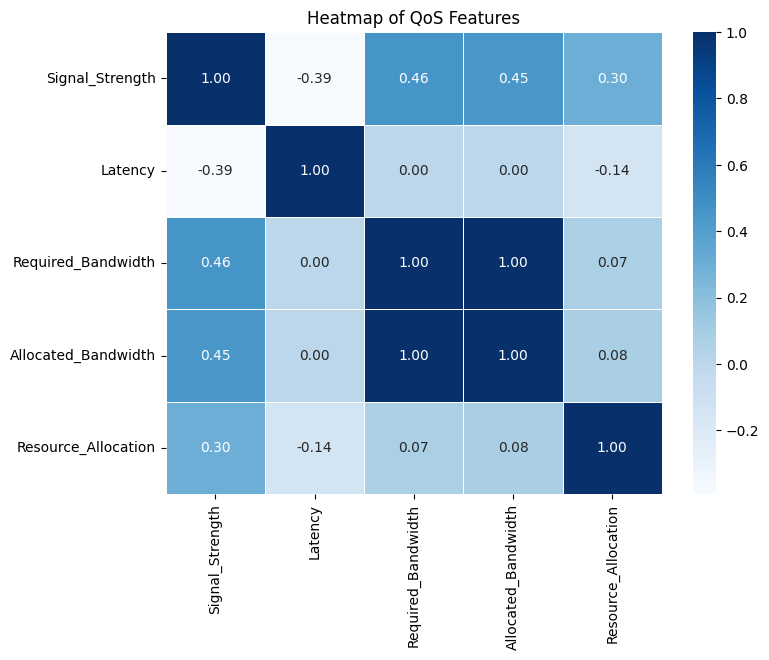

In [4]:
numeric_vars = ["Signal_Strength", "Latency", "Required_Bandwidth", "Allocated_Bandwidth", "Resource_Allocation"]

df_numeric = df[numeric_vars]
correlation_matrix = df_numeric.corr()

plot_heatmap(correlation_matrix)

- Z-score for numeric columns

Scaler returns numpy array, we convert it back to data frame

In [5]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

df_scaled

,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
0,0.265777,-0.181316,1.725130,2.580707,-0.525300
1,0.023942,-0.655346,-0.762862,-0.759195,0.589396
2,-0.217894,0.292713,0.468569,0.560605,0.032048
3,0.507612,-1.129376,-0.536680,-0.449446,1.704091
4,0.120676,-0.418331,-0.285368,-0.112762,1.146743
...,...,...,...,...,...
395,-1.427070,1.288176,-0.461287,-0.382109,1.146743
396,1.958624,0.908952,2.856035,2.760271,0.032048
397,-1.572171,1.145967,-0.536680,-0.471891,-0.525300
398,1.958624,-1.366391,-0.687468,-0.696347,-0.525300


- Elbow Method For K-means Algorithm

The optimal number of clusters is: 6


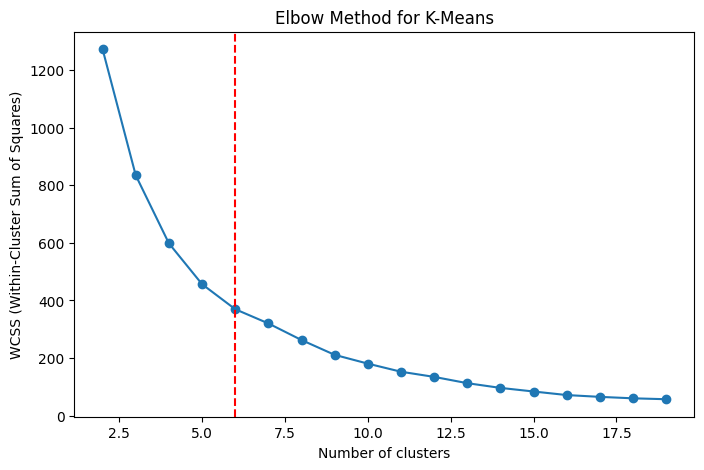

Optimal k based on C-Index: 17


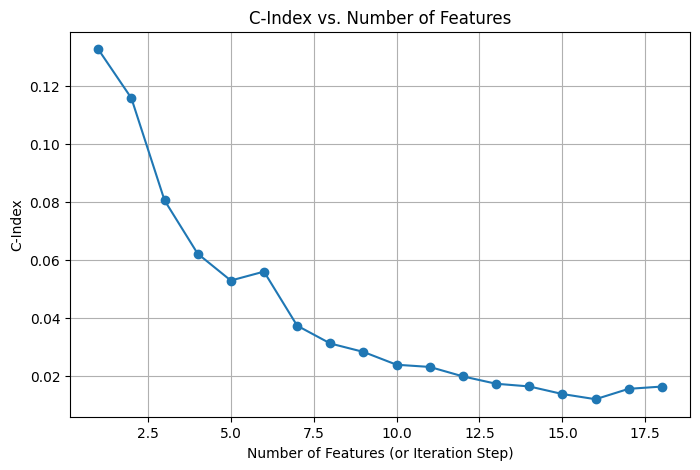

The optimal is: 6
Optimal K based on silhouette score: 16


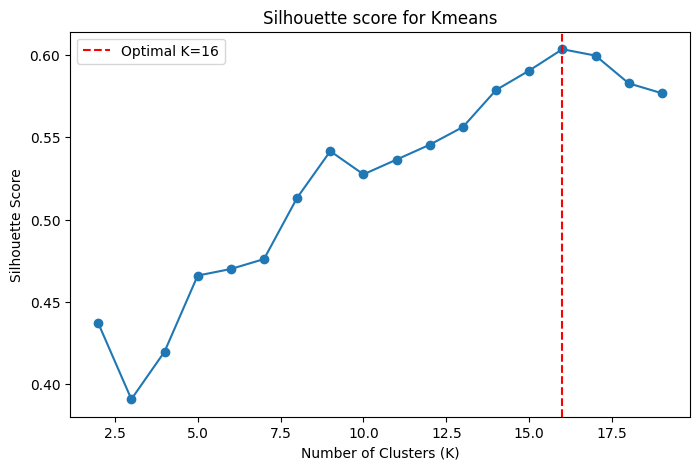

In [6]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

# K 2 - 366: 400 rows(/datapoints) in df_scaled - 34 duplicate rows
wcss = []  # Within-cluster sum of squares
c_index_kmeans = [] #C-index of each cluster iteration
silhouette_scores = []
data = df_scaled.values  # Convert to numpy array
K_range = range(2, min(20, len(df_scaled)))

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # kmeans.fit(df_scaled)
    labels_kmeans = kmeans.fit_predict(data)
    wcss.append(kmeans.inertia_)
    c_index_kmeans.append(compute_c_index(data, labels_kmeans))
    silhouette_scores.append(silhouette_score(df_scaled, labels_kmeans))

'''
Elbow Point
'''
# Use Knee Locator to find Elbow Point
kneedle = KneeLocator(list(K_range), wcss, curve="convex", direction="decreasing")
elbow_k = kneedle.elbow
print(f"The optimal number of clusters is: {elbow_k}")
plot_elbow_kmeans(elbow_k,K_range,wcss)

'''
C-index
'''
cindex_k = list(K_range)[np.argmin(c_index_kmeans)]
print(f"Optimal k based on C-Index: {cindex_k}")
plot_c_index(c_index_kmeans)
kneedle_ci = KneeLocator(list(K_range), c_index_kmeans, curve="convex", direction="decreasing")
# Get the elbow point (optimal k)
elbow = kneedle_ci.elbow
print(f"The optimal is: {elbow}")

'''
Highest Silhouette Score
'''
silhouette_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal K based on silhouette score: {silhouette_k}")
plot_silhouette_scores(silhouette_k,K_range,silhouette_scores,"Silhouette score for Kmeans")


- Run K-means Algorithm for optimal number of clusters

In [7]:
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
kmeans_cluster_labels = kmeans.fit_predict(df_scaled)

- Ward Linkage Method

Ward linkage is a method used in hierarchical clustering to determine the distance between two clusters before merging them.
The goal of Ward linkage is to minimize the increase in variance within the newly formed cluster when two clusters are combined.

https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html

- Dendogram for agglomerative with Ward Method

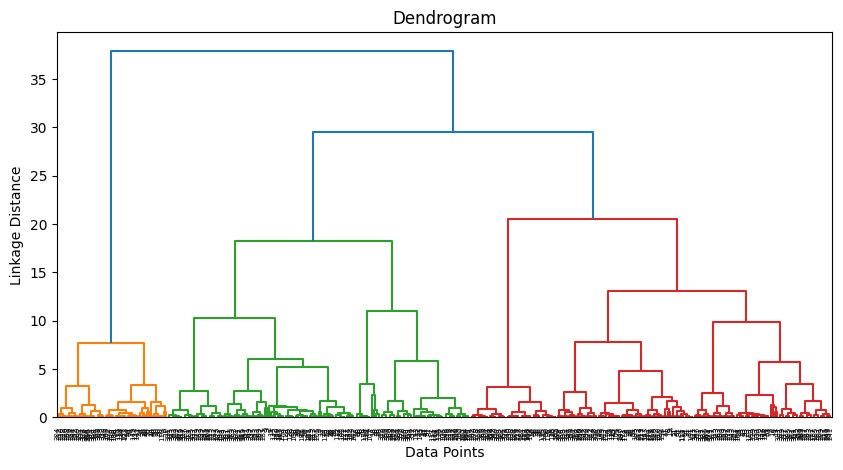

In [8]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Compute the Ward linkage matrix
linkage_matrix = sch.linkage(df_scaled, method='ward')

plot_dendogram(linkage_matrix)

- Find Elbow in dendogram

The optimal number of clusters is: 29


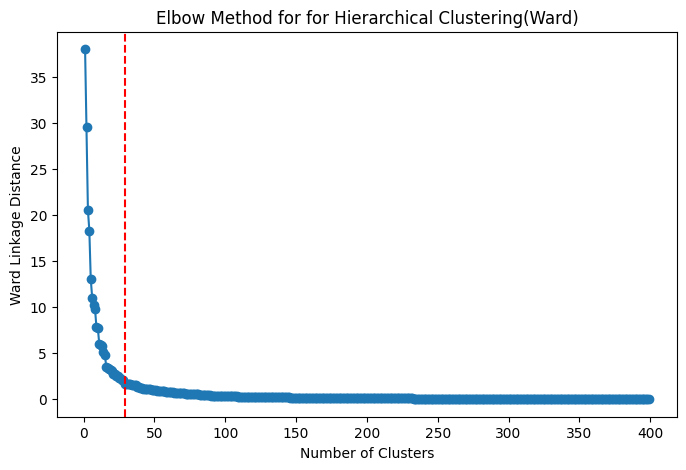

Optimal number of clusters from Silhouette Score: 18


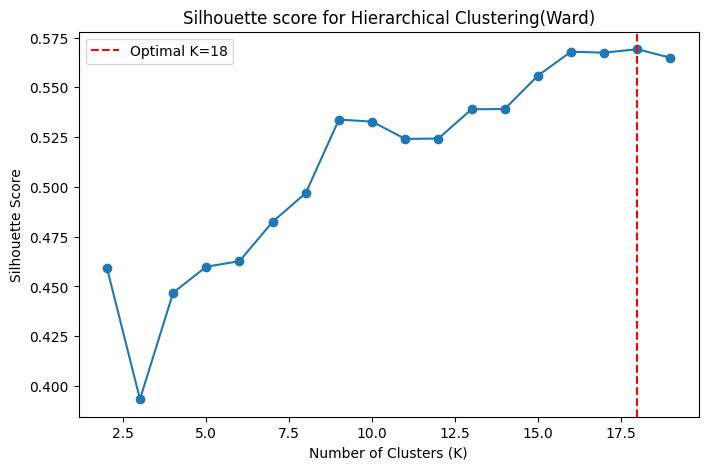

In [9]:
# Extract the distances at which clusters merge
distances = linkage_matrix[:, 2]  # Column 2 contains the distances
num_clusters = range(len(distances), 0, -1)

# Use KneeLocator to find the optimal number of clusters
hier_kneedle = KneeLocator(num_clusters, distances, curve="convex", direction="decreasing")

hier_elbow_k = hier_kneedle.elbow
print(f"The optimal number of clusters is: {hier_elbow_k}")

plot_elbow_ward(hier_elbow_k, num_clusters, distances)

hier_silhouette_scores = []

for k in K_range:
    cluster_labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(df_scaled)
    score = silhouette_score(df_scaled, cluster_labels)
    hier_silhouette_scores.append(score)
    
    # Find the best K (highest silhouette score)
optimal_silhouette_k = K_range[np.argmax(hier_silhouette_scores)]
print(f"Optimal number of clusters from Silhouette Score: {optimal_silhouette_k}")
plot_silhouette_scores(optimal_silhouette_k,K_range,hier_silhouette_scores,"Silhouette score for Hierarchical Clustering(Ward)")

- Apply Hierarchical Agglomerative Clustering Algorithm with Ward Linkage distance metric

In [10]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=hier_elbow_k, linkage='ward')
hierarchical_cluster_labels = hierarchical.fit_predict(df_scaled)